In [4]:
from torchvision.io import decode_image
from pathlib import Path

file = Path("/home/anselm/projects/verovio/build/anselm_001.png")
image = decode_image(file.as_posix())
image.shape


torch.Size([3, 2970, 2100])

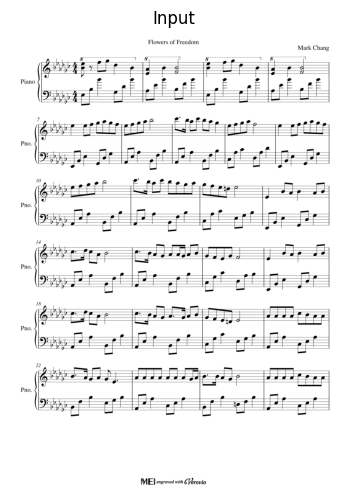

In [5]:
import cv2
import matplotlib.pyplot as plt

def imshow(title, img):
    if img.shape[-1] == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()
    
imshow("Input", image.permute(1,2,0).cpu().numpy())

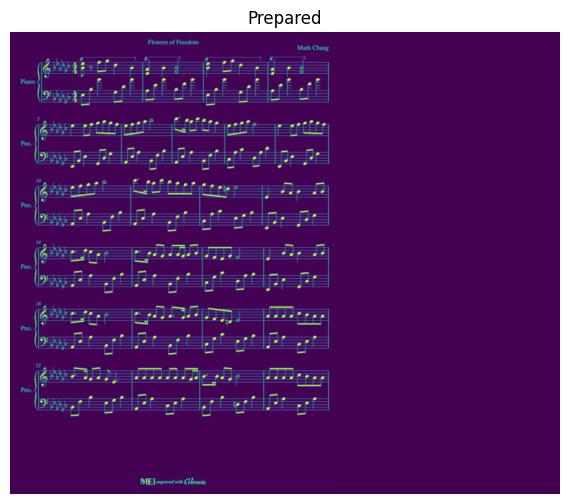

In [6]:
from model import Config
from dataset import StaffDataset

config = Config()
_, ds = StaffDataset.create(config=config)
image, _ = ds.predict_transform(image)

imshow("Prepared", image.permute(1,2,0).cpu().numpy())


In [22]:
from light import LitStaffer
import torch

checkpoint_file = "./checkpoints/some_run/last.ckpt"
checkpoint = torch.load(checkpoint_file, weights_only=False)
hparams = checkpoint["hyper_parameters"]

Config(**hparams)
model = LitStaffer.load_from_checkpoint(checkpoint_file, config=config, weights_only=False)
# model.hparams

# config2 = Config(**model.hparams)
# config2